In [20]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import os
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import defaultdict

from bci.signal.ssvep import SSVEPDetector,FlickerResult
from bci.ml.classifiers import ImageryClassifier, ActiveClassifier, MixedClassifier
from bci.ml.voting import PredictionAccumulator
from bci.signal.preprocessing import preprocess_global

In [21]:
# ==========================================
# CHANGE THESE
# ==========================================

LOG_FILE = "../data/22-05/s2_log.csv"
EEG_FILE = "../data/22-05/s2_eeg.txt"

# ==========================================
# EEG SETTINGS
# ==========================================

SAMPLE_RATE = 125
EPOCH_SEC = 1
OVERLAP = (1 - 0.8)

EPOCH_SAMPLES = SAMPLE_RATE * EPOCH_SEC
STRIDE = int(OVERLAP * SAMPLE_RATE)

In [22]:
# ==========================================
# FIND HEADER
# ==========================================

with open(EEG_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()

header_idx = None

for i, line in enumerate(lines):
    if "Sample Index" in line:
        header_idx = i
        break

if header_idx is not None:
    print("Header found at line:", header_idx)
else:
    print("Header not found")

eeg_df = pd.read_csv(
    EEG_FILE,
    skiprows=header_idx
)

# Clean column names
eeg_df.columns = [c.strip() for c in eeg_df.columns]

print("Shape:", eeg_df.shape)

# eeg_df.head()

eeg_channels = [f"EXG Channel {i}" for i in range(16)]

eeg_data = eeg_df[eeg_channels].values

print("EEG Shape:", eeg_data.shape)

eeg_time = pd.to_datetime(
    eeg_df["Timestamp (Formatted)"]
)

eeg_time.head()
# type(eeg_time.iloc[0])
log_df = pd.read_csv(LOG_FILE)

record_date = eeg_time.iloc[0].date()

log_df["DateTime"] = pd.to_datetime(
    str(record_date) + " " + log_df["Time"]
)

log_df.head()

Header found at line: 4
Shape: (64455, 33)
EEG Shape: (64455, 16)


,Time,Experiment,Phase,Event,Detail,Action,DateTime
0,16:38:42.790,TrainML,MLTrain,LSL_Connected,BCIBackend,BCI_Stream_Open,2026-05-22 16:38:42.790
1,16:38:42.790,TrainML,MLTrain,Experiment_Start,TrainML,NaN,2026-05-22 16:38:42.790
2,16:38:42.790,TrainML,MLTrain,Phase_Start,MLTrain,NaN,2026-05-22 16:38:42.790
3,16:38:42.845,TrainML,MLTrain,Hover_Enter,Button: StartTestBCI,Hovering,2026-05-22 16:38:42.845
4,16:38:42.848,TrainML,MLTrain,Dwell_Start,Button: StartTestBCI,Dwell_Started,2026-05-22 16:38:42.848


In [23]:
#preprocess
Notch_freq = 50.0
def preprocess_epoch(
    epoch: np.array,
    low: float = 3.0,
    high: float = 60.0
    ):
    epoch_filt = epoch.copy()
    nyq = SAMPLE_RATE/2.0
    if Notch_freq < nyq:
        b_notch, a_notch = signal.iirnotch(Notch_freq/nyq, 30.0)
        epoch_filt = signal.filtfilt(b_notch,a_notch,epoch_filt,axis=0)
    sos = signal.butter(4,[low, high],btype = "bandpass", fs = SAMPLE_RATE, output = "sos")
    epoch_filt = signal.sosfiltfilt(sos,epoch_filt,axis =0)
    return epoch_filt

In [24]:
def preprocess_events(
    event_epochs,
    remove_blinks=True,
    low=3.0,
    high=40.0
):

    processed = {}

    for event_name, data in event_epochs.items():

        epochs = data["epochs"]

        if remove_blinks:
            epochs = epochs[
                ~data["blink_mask"]
            ]

        epochs = np.array([
            preprocess_epoch(
                epoch,
                low,
                high
            )
            for epoch in epochs
        ])

        processed[event_name] = epochs

    return processed

In [25]:
def get_segment(start_time, end_time):
    mask = (eeg_time >= start_time) & \
           (eeg_time <= end_time)
    
    return eeg_data[mask.values]

def create_epochs(segment, epoch_len, stride):
    epochs = []

    for start in range(0, len(segment) - epoch_len + 1, stride):
        epoch = segment[start:start + epoch_len]
        epochs.append(epoch)

    return np.array(epochs)

In [26]:
def extract_intervals(df):

    intervals = defaultdict(list)

    active_events = {}

    current_blink_start = None

    for _, row in df.iterrows():

        action = str(row["Action"]).strip()
        time = row["DateTime"]

        # -------------------------
        # Blink handling
        # -------------------------

        if action == "Eye_Closed":

            current_blink_start = time
            continue

        elif action == "Eye_Opened":

            if current_blink_start is not None:

                blink = {
                    "start": current_blink_start,
                    "end": time
                }

                # add blink to all currently active events
                for event in active_events.values():
                    event["blinks"].append(blink)

                current_blink_start = None

            continue

        # -------------------------
        # Event handling
        # -------------------------

        parts = action.rsplit("_", 1)

        if len(parts) != 2:
            continue

        base, suffix = parts

        if suffix == "Start":

            active_events[base] = {
                "start": time,
                "blinks": []
            }

        elif suffix == "End":

            if base in active_events:

                event = active_events.pop(base)

                intervals[base].append({
                    "start": event["start"],
                    "end": time,
                    "blinks": event["blinks"],
                    "has_blink": len(event["blinks"]) > 0
                })

    return intervals

In [27]:
det = extract_intervals(df=log_df)

In [28]:
det

defaultdict(list,
            {'Flicker': [{'start': Timestamp('2026-05-22 16:38:49.759000'),
               'end': Timestamp('2026-05-22 16:38:51.769000'),
               'blinks': [],
               'has_blink': False}],
             'Training_Active_Door1_Flicker': [{'start': Timestamp('2026-05-22 16:38:53.778000'),
               'end': Timestamp('2026-05-22 16:38:57.787000'),
               'blinks': [],
               'has_blink': False},
              {'start': Timestamp('2026-05-22 16:39:29.891000'),
               'end': Timestamp('2026-05-22 16:39:33.902000'),
               'blinks': [],
               'has_blink': False},
              {'start': Timestamp('2026-05-22 16:39:53.968000'),
               'end': Timestamp('2026-05-22 16:39:57.977000'),
               'blinks': [{'start': Timestamp('2026-05-22 16:39:54.558000'),
                 'end': Timestamp('2026-05-22 16:39:54.656000')}],
               'has_blink': True},
              {'start': Timestamp('2026-05-22 16:40

In [29]:
def build_event_epochs(events_dict):

    event_epochs = {}

    for event_name, intervals in events_dict.items():

        # Skip Trial_Sequence
        if event_name == "Trial_Sequence":
            continue

        all_epochs = []
        all_blink_masks = []

        for interval in intervals:

            segment = get_segment(
                interval["start"],
                interval["end"]
            )

            # Skip if segment is too short
            if len(segment) < EPOCH_SAMPLES:
                continue

            epochs = create_epochs(
                segment,
                EPOCH_SAMPLES,
                STRIDE
            )

            blink_mask = np.zeros(
                len(epochs),
                dtype=bool
            )

            # Check each epoch for blink overlap
            for epoch_idx in range(len(epochs)):

                epoch_start = (
                    interval["start"]
                    + pd.Timedelta(
                        seconds=(epoch_idx * STRIDE) / SAMPLE_RATE
                    )
                )

                epoch_end = (
                    epoch_start
                    + pd.Timedelta(seconds=EPOCH_SEC)
                )

                has_blink = any(
                    blink["start"] <= epoch_end
                    and
                    blink["end"] >= epoch_start
                    for blink in interval.get("blinks", [])
                )

                blink_mask[epoch_idx] = has_blink

            all_epochs.append(epochs)
            all_blink_masks.append(blink_mask)

        if len(all_epochs) == 0:
            continue

        event_epochs[event_name] = {

            "epochs": np.concatenate(
                all_epochs,
                axis=0
            ),

            "blink_mask": np.concatenate(
                all_blink_masks,
                axis=0
            )
        }

    return event_epochs

In [30]:
event_epoch = build_event_epochs(extract_intervals(log_df))


In [31]:
filtered = preprocess_events(
    event_epoch,
    remove_blinks=True,
    low=3.0,
    high=60.0
)
# shorthand helper
E = filtered

for name, data in E.items():
    print(name, data.shape)

Flicker (6, 125, 16)
Training_Active_Door1_Flicker (156, 125, 16)
Training_Imagery_Door1_Flicker (147, 125, 16)
Training_Active_Door1 (160, 125, 16)
Training_Imagery_Door1 (137, 125, 16)
Active_Training_Door2 (160, 125, 16)
Training_Imagery_Door2 (160, 125, 16)
Active_Predict_1 (16, 125, 16)
Predict_Imagery_1 (16, 125, 16)
Active_Predict_2 (16, 125, 16)
Predict_Imagery_2 (16, 125, 16)
Active_Predict_3 (16, 125, 16)
Predict_Imagery_3 (16, 125, 16)
Active_Predict_4 (16, 125, 16)
Predict_Imagery_4 (9, 125, 16)
Active_Predict_5 (15, 125, 16)
Predict_Imagery_5 (16, 125, 16)


In [32]:
##confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

In [33]:
def build_dataset(*groups):
    X = np.concatenate([g[0] for g in groups])
    y = np.concatenate([np.full(len(g[0]), g[1])for g in groups])
    return X, y

def train_test_model(model,X,y,title="Model",test_size=0.2,random_state=42):
    # -----------------------------
    # Split
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=test_size,random_state=random_state,stratify=y)

    X_train = np.transpose(X_train, (0, 2, 1))
    X_test  = np.transpose(X_test, (0, 2, 1))
    # -----------------------------
    # Train
    # -----------------------------
    model.train(
        data=list(X_train),
        labels=list(y_train)
    )

    # -----------------------------
    # Evaluate
    # -----------------------------
    rows = []

    for x, y_true in zip(X_test, y_test):

        pred, conf = model.predict(x)

        rows.append({
            "true": y_true,
            "pred": pred,
            "correct": int(pred == y_true),
            "confidence": conf
        })

    df = pd.DataFrame(rows)

    # -----------------------------
    # Metrics
    # -----------------------------
    accuracy = df["correct"].mean()

    print("\n==============================")
    print(title)
    print("==============================")

    print("Accuracy:", accuracy)

    print("\nClassification Report:")
    print(classification_report(df["true"], df["pred"]))

    plot_confusion_matrix(
        df["true"],
        df["pred"],
        title=f"{title} Confusion Matrix"
    )

    return model, df

In [34]:
def run_ap(model, X, acc, name):
    results = []

    for epoch in X:
        pred, conf = model.predict(epoch.T)

        acc.append(pred, conf, imagery_str="NA", imagery_conf=0.0)

        stable = acc.get_stable_prediction(name)

        if stable is not None:
            results.append(stable)
            acc.clear()

    return results

def print_ap_results(name, results):
    for i, res in enumerate(results):
        print(
            f"[{name} {i+1}] "
            f"Pred: {res['prediction']} | "
            f"Conf: {res['confidence']:.3f} | "
            f"Agree: {res['agreement']:.3f} | "
            f"Model: {res['model_name']}"
        )

acc_active = PredictionAccumulator(10,0.7,0.6)
img_active = PredictionAccumulator(10,0.7,0.6)
mix_active = PredictionAccumulator(10,0.7,0.6)

Computing rank from data with rank=None
    Using tolerance 8.7 (2.2e-16 eps * 16 dim * 2.5e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.



Active Model
Accuracy: 0.7109375

Classification Report:
              precision    recall  f1-score   support

           1       0.70      0.73      0.72       128
           2       0.72      0.70      0.71       128

    accuracy                           0.71       256
   macro avg       0.71      0.71      0.71       256
weighted avg       0.71      0.71      0.71       256



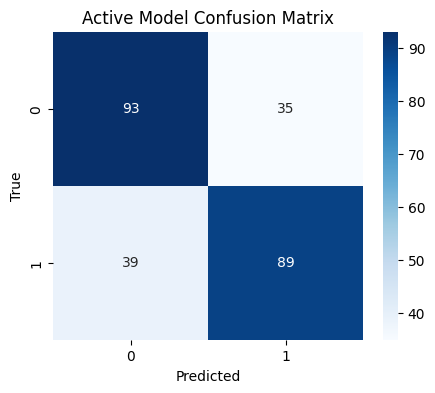

In [35]:
X_active, y_active = build_dataset(
    (E["Training_Active_Door1"], 1),
    (E["Active_Training_Door2"], 2)
)

active_model, active_df = train_test_model(
    ImageryClassifier(),
    X_active,
    y_active,
    test_size=0.8,
    title="Active Model"
)

In [36]:
AP1_active = run_ap(active_model, E["Active_Predict_1"], acc_active, "Active Test 1")
acc_active.clear()

AP2_active = run_ap(active_model, E["Active_Predict_2"], acc_active, "Active Test 2")
acc_active.clear()

AP3_active = run_ap(active_model, E["Active_Predict_3"], acc_active, "Active Test 3")
acc_active.clear()

AP4_active = run_ap(active_model, E["Active_Predict_4"], acc_active, "Active Test 4")
acc_active.clear()

AP5_active = run_ap(active_model, E["Active_Predict_5"], acc_active, "Active Test 5")
acc_active.clear()

print_ap_results("AP1 Active", AP1_active)
print("-------------------------------------------")
print_ap_results("AP2 Active", AP2_active)
print("-------------------------------------------")
print_ap_results("AP3 Active", AP3_active)
print("-------------------------------------------")
print_ap_results("AP4 Active", AP4_active)
print("-------------------------------------------")
print_ap_results("AP5 Active", AP5_active)

[AP1 Active 1] Pred: 2 | Conf: 0.895 | Agree: 0.700 | Model: Active Test 1
-------------------------------------------
[AP2 Active 1] Pred: 2 | Conf: 0.889 | Agree: 0.900 | Model: Active Test 2
-------------------------------------------
[AP3 Active 1] Pred: 2 | Conf: 0.912 | Agree: 1.000 | Model: Active Test 3
-------------------------------------------
[AP4 Active 1] Pred: 2 | Conf: 0.955 | Agree: 1.000 | Model: Active Test 4
-------------------------------------------
[AP5 Active 1] Pred: 2 | Conf: 0.948 | Agree: 1.000 | Model: Active Test 5


Computing rank from data with rank=None
    Using tolerance 10 (2.2e-16 eps * 16 dim * 2.8e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.

Imagery Model
Accuracy: 0.7100840336134454

Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.75      0.70       110
           2       0.76      0.68      0.72       128

    accuracy                           0.71       238
   macro avg       0.71      0.71      0.71       238
weighted avg       0.71      0.71      0.71       238



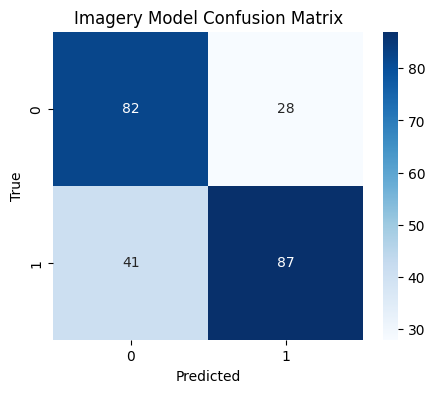

In [37]:
X_img, y_img = build_dataset((E["Training_Imagery_Door1"], 1),(E["Training_Imagery_Door2"], 2))

imagery_model, active_df = train_test_model(
    ImageryClassifier(),
    X_img,
    y_img,
    test_size=0.8,
    title="Imagery Model"
)

In [38]:
IP1_active = run_ap(imagery_model, E["Predict_Imagery_1"], img_active, "Imagery Test 1")
img_active.clear()

IP2_active = run_ap(imagery_model, E["Predict_Imagery_2"], img_active, "Imagery Test 2")
img_active.clear()

IP3_active = run_ap(imagery_model, E["Predict_Imagery_3"], img_active, "Imagery Test 3")
img_active.clear()

IP4_active = run_ap(imagery_model, E["Predict_Imagery_4"], img_active, "Imagery Test 4")
img_active.clear()

IP5_active = run_ap(imagery_model, E["Predict_Imagery_5"], img_active, "Imagery Test 5")
img_active.clear()

print_ap_results("Test 2 Imagery Active", IP1_active)
# print_ap_results("Test 2 Imagery Mix", IP1_mix)
print("-------------------------------------------")
print_ap_results("Test 2 Imagery Active", IP2_active)
# print_ap_results("Test 2 Imagery Mix", IP2_mix)
print("-------------------------------------------")
print_ap_results("Test 2 Imagery Active", IP3_active)
# print_ap_results("Test 2 Imagery Mix", IP3_mix)
print("-------------------------------------------")
print_ap_results("Test 2 Imagery Active", IP4_active)
# print_ap_results("Test 2 Imagery Mix", IP4_mix)
print("-------------------------------------------")
print_ap_results("Test 2 Imagery Active", IP5_active)
# print_ap_results("Test 2 Imagery Mix", IP5_mix)

[Test 2 Imagery Active 1] Pred: 2 | Conf: 0.668 | Agree: 1.000 | Model: Imagery Test 1
-------------------------------------------
-------------------------------------------
[Test 2 Imagery Active 1] Pred: 2 | Conf: 0.729 | Agree: 0.700 | Model: Imagery Test 3
-------------------------------------------
-------------------------------------------
[Test 2 Imagery Active 1] Pred: 1 | Conf: 0.653 | Agree: 0.800 | Model: Imagery Test 5
